## Instalación de librerias

In [ ]:
!pip install torchgeo lightning kornia
!pip install lightning torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.2/825.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Librerias

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models.segmentation as segmodels
import torch
import torchmetrics
from torchmetrics import JaccardIndex

from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning import Trainer
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as F
import random



# 2. Carga de base de datos DeepGlobal

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Colab/Geotermia/DeepGlobe"
TRAIN_IMG_DIR = f"{BASE_DIR}/training_data/images"
TRAIN_MASK_DIR = f"{BASE_DIR}/training_data/masks"
TEST_IMG_DIR  = f"{BASE_DIR}/test_data/images"
TEST_MASK_DIR = f"{BASE_DIR}/test_data/masks"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preprocesamiento y transformación del dataset

# Carga de imágenes y máscaras

In [ ]:

class SatelliteSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

        # Lista de imágenes
        self.image_paths = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]


        mask_filename = img_path.name.replace("_sat.jpg", "_mask.png")
        mask_path = self.mask_dir / mask_filename

        # Cargar imagen RGB y máscara
        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        return {"image": image, "mask": mask}


# Emparejamiento/Concatenación de imágenes y máscaras

In [ ]:
ds = SatelliteSegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)

print("Número de pares:", len(ds))

sample = ds[0]
print("Imagen:", sample["image"].size)
print("Mascara:", sample["mask"].size)


Número de pares: 683
Imagen: (2448, 2448)
Mascara: (2448, 2448)


# Mapa de colores y transformación de las imágenes

In [ ]:

# MAPA DE COLORES (DeepGlobe)

COLOR_MAP = {
    (0,   255, 255): 0,  # Urban (cyan)
    (255, 255,   0): 1,  # Agriculture (yellow)
    (255,   0, 255): 2,  # Rangeland (magenta)
    (0,   255,   0): 3,  # Forest (green)
    (0,     0, 255): 4,  # Water (blue)
    (255, 255, 255): 5,  # Barren (white)
    (0,     0,   0): 6,  # Unknown (black)
}


# Convertir RGB

def rgb_to_class(mask_rgb):
    mask_rgb = np.array(mask_rgb)
    h, w, _ = mask_rgb.shape
    mask_class = np.zeros((h, w), dtype=np.int64)

    for color, cls in COLOR_MAP.items():
        r, g, b = color
        matches = (mask_rgb == [r, g, b]).all(axis=2)
        mask_class[matches] = cls

    return mask_class

class SimpleSegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
        self.img_transform = T.Compose([
            T.Resize(size, interpolation=InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
        self.mask_resize = T.Resize(size, interpolation=InterpolationMode.NEAREST)

    def __call__(self, image, mask):
        image = self.img_transform(image)
        mask = self.mask_resize(mask)
        mask = rgb_to_class(mask)
        mask = torch.from_numpy(mask).long()
        return image, mask


# Transformación para Train-Aumentación

class TrainSegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
        self.img_resize = T.Resize(size, interpolation=InterpolationMode.BILINEAR)
        self.mask_resize = T.Resize(size, interpolation=InterpolationMode.NEAREST)
        self.to_tensor = T.ToTensor()
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

    def __call__(self, image, mask):

# Aumentación

        # Flip horizontal
        if random.random() < 0.5:
            image = F.hflip(image)
            mask = F.hflip(mask)

        # Flip vertical
        if random.random() < 0.5:
            image = F.vflip(image)
            mask = F.vflip(mask)

        # Rotación pequeña
        angle = random.uniform(-10, 10)
        image = F.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        mask  = F.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        # Resize + normalize
        image = self.img_resize(image)
        image = self.to_tensor(image)
        image = self.normalize(image)

        mask = self.mask_resize(mask)
        mask = rgb_to_class(mask)
        mask = torch.from_numpy(mask).long()

        return image, mask


In [ ]:

class DeepGlobeFolderDataModule(L.LightningDataModule):
    def __init__(
        self,
        train_img_dir,
        train_mask_dir,
        test_img_dir,
        test_mask_dir,
        batch_size=4,
        num_workers=2,
        val_split_pct=0.2,
        img_size=(256, 256),
    ):
        super().__init__()
        self.train_img_dir = train_img_dir
        self.train_mask_dir = train_mask_dir
        self.test_img_dir = test_img_dir
        self.test_mask_dir = test_mask_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_split_pct = val_split_pct
        self.img_size = img_size

    def setup(self, stage=None):

        # transform con augmentación para entrenamiento

        transform_train = TrainSegmentationTransform(self.img_size)

        transform_eval  = SimpleSegmentationTransform(self.img_size)

        full_train = SatelliteSegmentationDataset(
            self.train_img_dir, self.train_mask_dir, transform=transform_train
        )

        n_total = len(full_train)
        n_val = int(self.val_split_pct * n_total)
        n_train = n_total - n_val

        self.train_dataset, self.val_dataset = random_split(
            full_train,
            [n_train, n_val],
            generator=torch.Generator().manual_seed(42),
        )


        self.test_dataset = SatelliteSegmentationDataset(
            self.test_img_dir, self.test_mask_dir, transform=transform_eval
        )


        self.train_dataset.dataset.transform = transform_train
        self.val_dataset.dataset.transform   = transform_eval

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )


datamodule = DeepGlobeFolderDataModule(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    TEST_IMG_DIR, TEST_MASK_DIR,
    batch_size=4,
    num_workers=2,
    val_split_pct=0.2,
    img_size=(256, 256),
)

datamodule.setup()
batch = next(iter(datamodule.train_dataloader()))
print(batch["image"].shape, batch["mask"].shape)


torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


In [ ]:
NUM_CLASSES = 7  # Urban, Agriculture, Rangeland, Forest, Water, Barren, Unknown

def create_deeplab_resnet50(num_classes: int = NUM_CLASSES):
    model = segmodels.deeplabv3_resnet50(weights="DEFAULT")
    in_channels = model.classifier[4].in_channels
    model.classifier[4] = nn.Conv2d(in_channels, num_classes, kernel_size=1)
    return model

class LandCoverSegmentationModule(L.LightningModule):
    def __init__(self, num_classes: int = NUM_CLASSES, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = create_deeplab_resnet50(num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

        self.train_iou = torchmetrics.JaccardIndex(
            task="multiclass", num_classes=num_classes
        )
        self.val_iou = torchmetrics.JaccardIndex(
            task="multiclass", num_classes=num_classes
        )

    def forward(self, x):
        out = self.model(x)
        return out["out"]

    def training_step(self, batch, batch_idx):
        x, y = batch["image"], batch["mask"]
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = logits.argmax(dim=1)
        self.train_iou(preds, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_mIoU", self.train_iou, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch["image"], batch["mask"]
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = logits.argmax(dim=1)
        self.val_iou(preds, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_mIoU", self.val_iou, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        return optimizer


# Entrenamiento


*   Learning Rate de 1e-4
*   Earlystopping- Paciencia : 6
*   Epocas : 20


In [ ]:

# 1. Modelo con learning rate

model = LandCoverSegmentationModule(
    num_classes=NUM_CLASSES,
    lr=1e-4
)


# 2. EarlyStopping

early_stop = EarlyStopping(
    monitor="val_mIoU",
    mode="max",
    patience=6,
    verbose=True,
)


# 3. Checkpoint automático del mejor modelo

checkpoint = ModelCheckpoint(
    dirpath="checkpoints/",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    filename="best-deeplab-{epoch:02d}-{val_mIoU:.3f}",
    verbose=True,
)


# 4. Trainer final

trainer = Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early_stop, checkpoint],
)


# 5. Entrenamiento

trainer.fit(model, datamodule=datamodule)

best_path = checkpoint.best_model_path
print("Mejor modelo guardado en:", best_path)

best_model = LandCoverSegmentationModule.load_from_checkpoint(
    best_path,
    num_classes=NUM_CLASSES
)

print("Modelo cargado desde el mejor checkpoint.")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | DeepLabV3              | 42.0 M | train
1 | loss_fn   | CrossEntropyLoss       | 0      | train
2 | train_iou | MulticlassJaccardIndex | 0      | train
3 | val_iou   | MulticlassJaccardIndex | 0      | train
-------------------------------------------------------------
42.0 M    Trainable params
0         Non-trainable params
42.0 M    Total param

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Metric val_mIoU improved. New best score: 0.328
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_mIoU improved. New best score: 0.328
INFO: Epoch 0, global step 137: 'val_mIoU' reached 0.32786 (best 0.32786), saving model to '/content/checkpoints/best-deeplab-epoch=00-val_mIoU=0.328.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 137: 'val_mIoU' reached 0.32786 (best 0.32786), saving model to '/content/checkpoints/best-deeplab-epoch=00-val_mIoU=0.328.ckpt' as top 1


...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 18, global step 2603: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 18, global step 2603: 'val_mIoU' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 19, global step 2740: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 19, global step 2740: 'val_mIoU' was not in top 1
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Mejor modelo guardado en: /content/checkpoints/best-deeplab-epoch=17-val_mIoU=0.518.ckpt
Modelo cargado desde el mejor checkpoint.


# Visualización de imágen original + Ground Truth + Máscara predicha del conjunto de Train

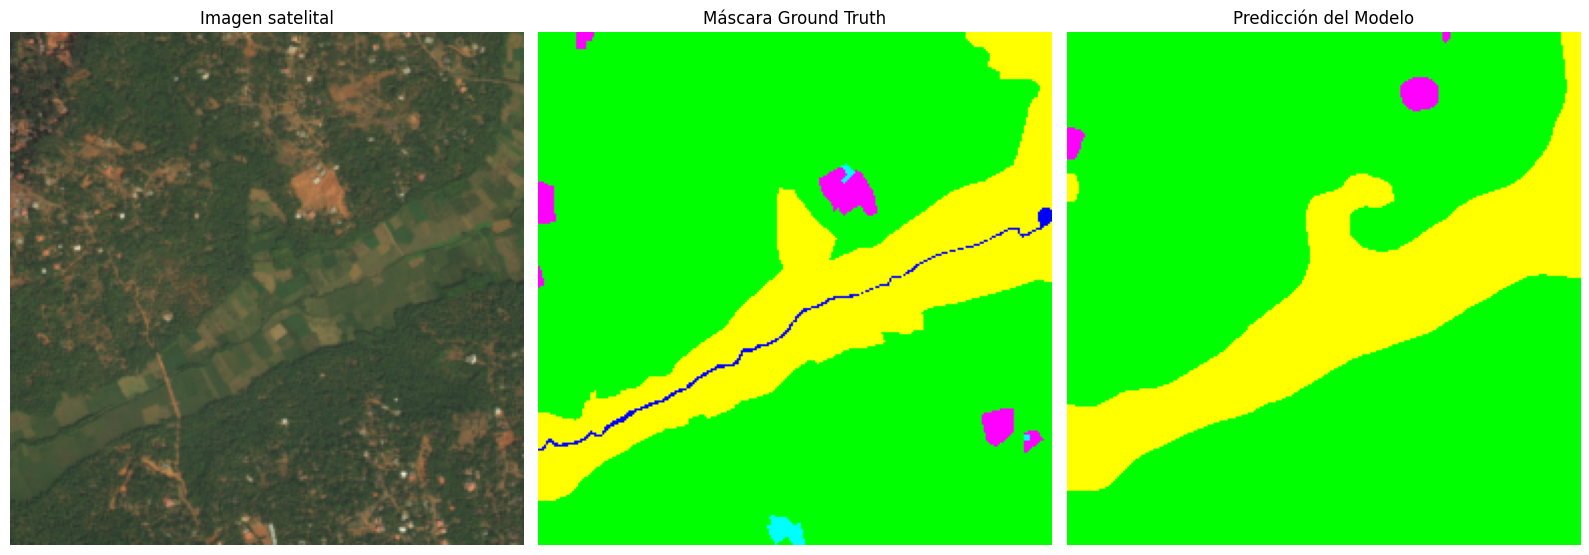

In [ ]:


INDEX2COLOR = {cls: color for color, cls in COLOR_MAP.items()}

def classes_to_rgb(mask_class):

    mask_class = mask_class.cpu().numpy()
    h, w = mask_class.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for cls, color in INDEX2COLOR.items():
        rgb[mask_class == cls] = color

    return rgb


#  batch del conjunto de validación

val_loader = datamodule.val_dataloader()
batch = next(iter(val_loader))

images = batch["image"]      # (B, 3, H, W)
masks  = batch["mask"]       # (B, H, W)

device = "cuda" if torch.cuda.is_available() else "cpu"
best_model.to(device)
best_model.eval()


# Predicciones del modelo

with torch.no_grad():
    logits = best_model(images.to(device))
    if isinstance(logits, dict):
        logits = logits["out"]
    preds = logits.argmax(dim=1).cpu()


# Visualización del primer ejemplo

idx = 0

img  = images[idx].cpu()       # (3, H, W)
gt   = masks[idx]              # (H, W)
pr   = preds[idx]              # (H, W)


mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

img_vis = (img * std + mean).clamp(0,1).permute(1,2,0).numpy()

# Convertir máscaras a RGB
gt_rgb = classes_to_rgb(gt)
pr_rgb = classes_to_rgb(pr)

plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
plt.title("Imagen satelital")
plt.imshow(img_vis)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Máscara Ground Truth")
plt.imshow(gt_rgb)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicción del Modelo")
plt.imshow(pr_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Ruta del mejor modelo
best_path = "/content/checkpoints/best-deeplab-epoch=17-val_mIoU=0.518.ckpt"
print("Cargando desde:", best_path)


fine_tuned_model = LandCoverSegmentationModule.load_from_checkpoint(
    best_path,
    num_classes=NUM_CLASSES,
    lr=1e-5
)

# Callbacks para  segundo entrenamiento
early_stop_ft = EarlyStopping(
    monitor="val_mIoU",
    mode="max",
    patience=4,
    verbose=True,
)

checkpoint_ft = ModelCheckpoint(
    dirpath="checkpoints_finetune/",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    filename="finetune-deeplab-{epoch:02d}-{val_mIoU:.3f}",
    verbose=True,
)

# Nuevo Trainer para el fine-tuning
trainer_ft = Trainer(
    max_epochs=15,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early_stop_ft, checkpoint_ft],
)


trainer_ft.fit(fine_tuned_model, datamodule=datamodule)

# Cargar el mejor modelo del fine-tuning

best_ft_path = checkpoint_ft.best_model_path
print("Mejor modelo de fine-tuning:", best_ft_path)

best_model_ft = LandCoverSegmentationModule.load_from_checkpoint(
    best_ft_path,
    num_classes=NUM_CLASSES
)

print("Modelo de fine-tuning cargado.")


Cargando desde: /content/checkpoints/best-deeplab-epoch=17-val_mIoU=0.518.ckpt


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | DeepLabV3              | 42.0 M | train
1 | loss_fn   | CrossEntropyLoss       | 0      | train
2 | train_iou | MulticlassJaccardIndex | 0      | train
3 | val_iou   | MulticlassJaccardIndex | 0      | train
-------------------------------------------------------------
42.0 M    Trainable params
0         Non-trainable params
42.0 M    Total param

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 10, global step 1507: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 10, global step 1507: 'val_mIoU' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_mIoU did not improve in the last 4 records. Best score: 0.526. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_mIoU did not improve in the last 4 records. Best score: 0.526. Signaling Trainer to stop.
INFO: Epoch 11, global step 1644: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 11, global step 1644: 'val_mIoU' was not in top 1


Mejor modelo de fine-tuning: /content/checkpoints_finetune/finetune-deeplab-epoch=07-val_mIoU=0.526.ckpt
Modelo de fine-tuning cargado.


# Métrica Global y por clases del conjunto de Test

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"


model_eval = best_model_ft.to(device)
model_eval.eval()

test_loader = datamodule.test_dataloader()


miou_global = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)

miou_per_class = JaccardIndex(
    task="multiclass", num_classes=NUM_CLASSES, average=None
).to(device)

with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device)
        y = batch["mask"].to(device)

        logits = model_eval(x)
        if isinstance(logits, dict):
            logits = logits["out"]

        preds = logits.argmax(dim=1)

        miou_global.update(preds, y)
        miou_per_class.update(preds, y)

test_miou = miou_global.compute().item()
miou_classes = miou_per_class.compute().cpu().numpy()

print(f"\n=== mIoU GLOBAL en test: {test_miou:.3f} ===\n")
clases = ["Urban", "Agriculture", "Rangeland", "Forest", "Water", "Barren", "Unknown"]
for i, m in enumerate(miou_classes):
    print(f"Clase {i} ({clases[i]}): IoU = {m:.3f}")



=== mIoU GLOBAL en test: 0.554 ===

Clase 0 (Urban): IoU = 0.689
Clase 1 (Agriculture): IoU = 0.819
Clase 2 (Rangeland): IoU = 0.268
Clase 3 (Forest): IoU = 0.764
Clase 4 (Water): IoU = 0.681
Clase 5 (Barren): IoU = 0.660
Clase 6 (Unknown): IoU = 0.000


# Visualización de la imágen original + Ground Truth + máscara predicha del conjunto de Test

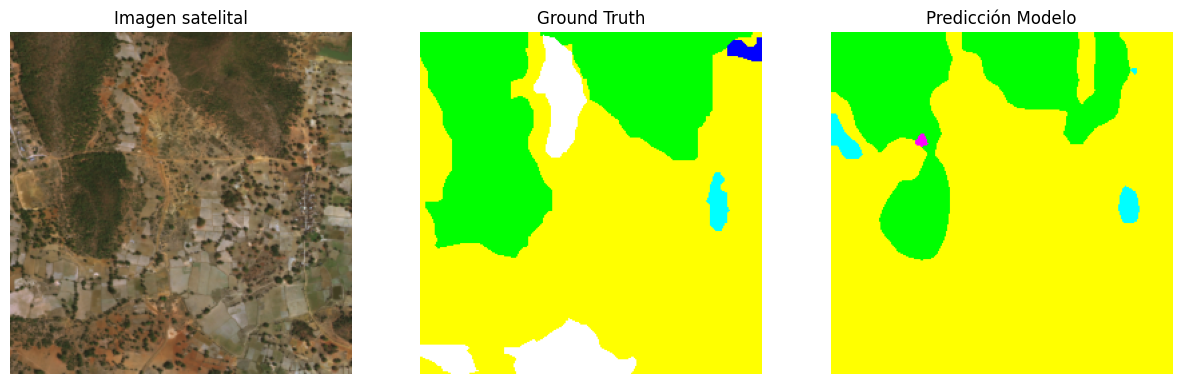

In [ ]:
idx = 30

dataset_test = datamodule.test_dataset

sample_test_item = dataset_test[idx]
image = sample_test_item["image"]
mask = sample_test_item["mask"]

img_tensor = image.unsqueeze(0).to(device)

model = best_model_ft.to(device)
model.eval()

with torch.no_grad():
    logits = model(img_tensor)
    if isinstance(logits, dict):
        logits = logits["out"]
    pred = logits.argmax(dim=1).squeeze().cpu()

img_vis = (image.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()
gt_rgb  = classes_to_rgb(mask)
pr_rgb  = classes_to_rgb(pred)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_vis); plt.axis("off"); plt.title("Imagen satelital")
plt.subplot(1,3,2); plt.imshow(gt_rgb); plt.axis("off"); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pr_rgb); plt.axis("off"); plt.title("Predicción Modelo")
plt.show()
